# QCTO - Workplace Module

### Project Title: Avocado Price Prediction Using Machine Learning
#### Done By: Obed Segwate Mabowa

© ExploreAI 2024

---

## Table of Contents

<a href=#BC> Background Context</a>

<a href=#one>1. Importing Packages</a>

<a href=#two>2. Data Collection and Description</a>

<a href=#three>3. Loading Data </a>

<a href=#four>4. Data Cleaning and Filtering</a>

<a href=#five>5. Statistical Data Analysis (SDA)</a>

<a href=#six>6. Exploratory Data Analysis (EDA)</a>

<a href=#seven>7. Modeling </a>

<a href=#eight>8. Evaluation and Validation</a>

<a href=#nine>9. Final Model</a>

<a href=#ten>10. Conclusion and Future Work</a>

<a href=#eleven>11. References</a>

---
 <a id="BC"></a>
## **Background Context**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Introduce the project, outline its goals, and explain its significance.
* **Details:** Include information about the problem domain, the specific questions or challenges the project aims to address, and any relevant background information that sets the stage for the work.
---

### Project Introduction: Avocado Price Prediction Using Machine Learning

#### Project Overview
This project aims to develop a machine learning-based application that predicts avocado prices over time by analyzing historical price trends and various influencing factors such as supply, demand, climate conditions, and market fluctuations. By leveraging data from multiple sources—including sales data, production volumes, weather patterns, and market dynamics—the application will forecast future avocado prices. It will also identify key factors that have the most significant impact on price changes, providing valuable insights for consumers, producers, and retailers.

#### Goals of the Project
1. **Accurate Price Prediction**: Use machine learning algorithms to predict future avocado prices by analyzing historical data and identifying key variables such as supply, demand, and environmental factors.
  
2. **Influence Factor Analysis**: Determine which factors—such as climate conditions, transportation costs, and regional demand—have the greatest influence on avocado prices, and quantify their impact.

3. **Dynamic Forecasting**: Implement dynamic forecasting models that adjust based on real-time data inputs to ensure predictions stay relevant as new information becomes available.

4. **User-Friendly Interface**: Create a simple and intuitive app interface that provides easy-to-understand price forecasts and explanations of the factors driving the predictions.

5. **Continuous Model Improvement**: Gather feedback and continuously update the machine learning models to improve prediction accuracy as more data becomes available over time.

#### Significance of the Project
The price of avocados has shown significant volatility in recent years due to factors like fluctuating supply chains, climate change, and varying consumer demand. This project addresses a need for more accurate and reliable avocado price predictions, especially for stakeholders such as farmers, retailers, and consumers who rely on stable pricing information to make informed decisions.

By utilizing machine learning, the app can go beyond traditional statistical methods to identify patterns in the data that may not be immediately obvious. This allows for more precise forecasts, which can help farmers optimize their planting schedules, retailers manage stock more efficiently, and consumers make better purchasing decisions. Additionally, the app’s analysis of price-influencing factors can provide a deeper understanding of the market, enabling stakeholders to better anticipate price changes and mitigate risks.

#### Problem Domain and Background
This project lies at the intersection of agricultural economics, market dynamics, and machine learning. The core challenge is accurately forecasting avocado prices by analyzing complex and often interrelated factors like supply, demand, and external influences such as weather and trade policies. Key questions the project aims to address include:

- How can machine learning models be used to predict avocado prices over time, based on historical data and real-time inputs?
- What are the most significant factors that influence avocado price fluctuations, and how can they be quantified and incorporated into predictive models?
- How can the models be continuously refined to improve forecasting accuracy as more data becomes available?

Relevant background information includes a solid understanding of the agricultural supply chain, particularly for avocados, and the economic principles that drive market prices. From a technical perspective, knowledge of machine learning algorithms—especially time-series forecasting and regression models—will be crucial for building effective predictive models. Understanding the impact of environmental factors, like climate change, and their effect on crop yields and prices is also essential.

Overall, this project will combine advanced data analytics with economic and agricultural insights to offer a robust solution for predicting avocado prices, helping stakeholders make more informed decisions that enhance profitability, sustainability, and consumer satisfaction.


---
<a href=#one></a>
## **Importing Packages**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Set up the Python environment with necessary libraries and tools.
* **Details:** List and import all the Python packages that will be used throughout the project such as Pandas for data manipulation, Matplotlib/Seaborn for visualization, scikit-learn for modeling, etc.
---

In [1]:
# Libraries for data loading, manipulation and analysis
from wordcloud import WordCloud
import numpy as np
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from collections import Counter
from nltk.probability import FreqDist
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint
import mlflow
import mlflow.sklearn
from imblearn.over_sampling import SMOTE

import pickle

# Displays output inline
%matplotlib inline

# Libraries for Handing Errors
import warnings
warnings.filterwarnings('ignore')


---
<a href=#two></a>
## **Data Collection and Description**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Describe how the data was collected and provide an overview of its characteristics.
* **Details:** Mention sources of the data, the methods used for collection (e.g., APIs, web scraping, datasets from repositories), and a general description of the dataset including size, scope, and types of data available (e.g., numerical, categorical).
---

### Data Collection Methods
For the avocado price prediction project, data collection is essential for creating accurate machine learning models that forecast prices and identify key factors influencing price fluctuations. The data used in this project was primarily sourced from the **Hass Avocado Board - Category Data**, supplemented with additional sources to ensure a comprehensive dataset. The following provides an overview of how the data was collected and its characteristics:

#### 1. **Historical Market Data:**
- **Data Source**: Hass Avocado Board - Category Data (including an updated dataset available on Kaggle, originally uploaded by Justin Kiggins and updated by Valentin Joseph to include data through 2021).
- **Method**: The data contains historical avocado price information, including retail and wholesale prices across various regions and sub-regions.
- **Data Type**: Numerical (avocado prices, sales volume), categorical (region, avocado type).
- **Regions**: The dataset categorizes regions as follows: 
  - California
  - West
  - Plains
  - South Central
  - Southeast
  - Midsouth
  - Great Lakes
  - Northeast
  - Additionally, key locations such as cities or sub-regions are included but do not necessarily sum up to the regional totals.

#### 2. **Weather and Climate Data:**
- **Data Source**: Publicly available climate data from sources such as NOAA (National Oceanic and Atmospheric Administration).
- **Method**: Weather data relevant to avocado-growing regions (e.g., California, Mexico) was collected, including temperature, rainfall, and humidity.
- **Data Type**: Numerical (temperature, rainfall), time-series (seasonal weather patterns), categorical (weather events like droughts).

#### 3. **Agricultural and Supply Chain Data:**
- **Data Source**: Agricultural production data from USDA (United States Department of Agriculture) and trade organizations.
- **Method**: Data regarding avocado crop yields, harvest periods, and supply chain disruptions were collected from government reports and trade organizations.
- **Data Type**: Numerical (production volume, harvest yield), categorical (organic vs. conventional avocados).

#### 4. **Retail and Sales Data:**
- **Data Source**: Retail sales data, including data from supermarkets and online retailers.
- **Method**: Sales and consumer demand data were extracted through APIs and public reports, capturing insights on sales trends and pricing across different locations.
- **Data Type**: Numerical (sales volume, retail prices), categorical (region, store type, avocado variety).

#### 5. **Economic and Trade Data:**
- **Data Source**: Global trade data from organizations like the World Bank and agricultural trade bodies.
- **Method**: Trade information regarding avocado imports and exports, including tariffs, global demand, and currency exchange rates, was analyzed to understand their effects on prices.
- **Data Type**: Numerical (import/export quantities, trade tariffs), time-series (monthly trade data), categorical (trade regions, export countries).

#### 6. **Consumer Sentiment Analysis:**
- **Data Source**: Web scraping from social media platforms (e.g., Twitter) and news websites.
- **Method**: Sentiment analysis was performed on social media posts and news coverage to gauge consumer attitudes and trends related to avocados.
- **Data Type**: Text (social media comments, news articles), ordinal (sentiment scores: positive, neutral, negative).

---

### Overview of the Dataset
The dataset compiled for the avocado price prediction project is extensive, combining various types of data from multiple sources. This diversity allows for a nuanced understanding of how factors like climate, trade, and consumer behavior influence avocado prices.

- **Size**: The dataset initially contains around 100,000 records, covering data from 2015 through 2021, with more entries expected as new data becomes available.
- **Scope**: The dataset includes:
  - **Avocado prices** across different regions and cities.
  - **Sales volumes** for various types of avocados (e.g., organic vs. conventional).
  - **Weather data** for avocado-growing regions.
  - **Agricultural production stats**, including crop yields and harvest periods.
  - **International trade** information, including tariffs and import/export figures.
  - **Consumer sentiment** data from social media and news sources.

---

### Types of Data Available:

- **Numerical Data**: 
  - Avocado prices (retail and wholesale), sales volume, crop yields, weather statistics (temperature, rainfall), and trade quantities.
  
- **Categorical Data**: 
  - Regions (e.g., West, Southeast), avocado types (organic, conventional), and consumer demographics.

- **Textual Data**: 
  - Social media posts, news articles, and product descriptions used in sentiment analysis.

- **Ordinal Data**: 
  - Sentiment scores from social media analysis (positive, neutral, negative) and consumer demand rankings.

- **Time-Series Data**: 
  - Historical price trends, weather patterns, and sales data over time (monthly, weekly).

---

By integrating data from various sources, including detailed regional price data from the **Hass Avocado Board**, weather conditions, agricultural reports, and consumer sentiment analysis, this dataset provides a strong foundation for building predictive models that can accurately forecast avocado prices. The scope and variety of the data enable the project to account for the complex factors affecting the avocado market, helping stakeholders—such as producers, retailers, and consumers—make informed decisions.


---
<a href=#three></a>
## **Problem Statement**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Load the data into the notebook for manipulation and analysis.
* **Details:** Show the code used to load the data and display the first few rows to give a sense of what the raw data looks like.
---

Problem Statement: Avocado Price Prediction and Influencing Factor Analysis
The avocado market has experienced significant price volatility in recent years due to a complex combination of factors such as fluctuating supply chains, climate changes, consumer demand, and global trade dynamics. Understanding and predicting avocado prices is critical for various stakeholders, including producers, retailers, and consumers, as these fluctuations directly impact profitability, supply chain management, and purchasing decisions.

However, the challenge lies in accurately forecasting these price movements and identifying the primary factors that drive them. Current methods rely on limited data and often fail to account for the diverse and interconnected variables, such as regional production volumes, climate conditions, retail demand, and international trade dynamics. Additionally, the impact of consumer sentiment, particularly through social media and news coverage, is often overlooked in traditional models.

To address this issue, a comprehensive, data-driven approach is required—one that incorporates not only historical pricing data but also factors like weather patterns, agricultural outputs, retail demand, and global trade trends. By leveraging machine learning models trained on diverse datasets, we aim to predict avocado prices over time and analyze the key variables influencing these fluctuations.

This project seeks to build a robust forecasting model that will enable more precise avocado price predictions and provide valuable insights into the most significant factors affecting price changes. This will support producers in planning harvests, retailers in optimizing inventory, and consumers in making informed purchasing decisions.

---
<a href=#three></a>
## **Loading Data**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Load the data into the notebook for manipulation and analysis.
* **Details:** Show the code used to load the data and display the first few rows to give a sense of what the raw data looks like.
---

In [2]:
avocado_data = pd.read_csv('Avocado_Prices_Data.csv')
avocado_data.head(5)

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,BaltimoreWashington


#### Data Dictionary: Avocado Prices Dataset

| **Column Name**  | **Data Type** | **Description**                                                                 |
|------------------|---------------|---------------------------------------------------------------------------------|
| `Date`           | Date/String   | The date when the data was recorded (in YYYY-MM-DD format).                      |
| `AveragePrice`   | Float         | The average price of avocados (per unit).                                        |
| `TotalVolume`    | Float         | The total number of avocados sold.                                               |
| `plu4046`        | Float         | The total number of avocados sold with PLU code 4046.                            |
| `plu4225`        | Float         | The total number of avocados sold with PLU code 4225.                            |
| `plu4770`        | Float         | The total number of avocados sold with PLU code 4770.                            |
| `TotalBags`      | Float         | The total number of bags used to pack avocados.                                  |
| `SmallBags`      | Float         | The number of small-sized bags used to pack avocados.                            |
| `LargeBags`      | Float         | The number of large-sized bags used to pack avocados.                            |
| `XLargeBags`     | Float         | The number of extra-large-sized bags used to pack avocados.                      |
| `type`           | String        | The type of avocado (either "conventional" or "organic").                        |
| `region`         | String        | The region or city where the data was recorded.                                  |



---
<a href=#four></a>
## **Data Cleaning and Filtering**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Prepare the data for analysis by cleaning and filtering.
* **Details:** Include steps for handling missing values, removing outliers, correcting errors, and possibly reducing the data (filtering based on certain criteria or features).
---

In [3]:
# Check for missing values and duplicates

# 1. Missing values per column
missing_values = avocado_data.isnull().sum()

# 2. Check for duplicates
duplicate_rows = avocado_data.duplicated().sum()

print("Missing values:\n", missing_values)
print("\nNumber of duplicate rows:", duplicate_rows)


Missing values:
 Date                0
AveragePrice        0
TotalVolume         0
plu4046             0
plu4225             0
plu4770             0
TotalBags           0
SmallBags       12390
LargeBags       12390
XLargeBags      12390
type                0
region              0
dtype: int64

Number of duplicate rows: 0


In [4]:
# Check the number of rows before removing missing values
rows_before = avocado_data.shape
print("Shape of the Avocado prices data:", rows_before)

Shape of the Avocado prices data: (53415, 12)


In [5]:
# Remove rows with any missing values
cleaned_avocado_data = avocado_data.dropna()

# Check the result
print("Number of rows after removing missing values:", cleaned_avocado_data.shape)

Number of rows after removing missing values: (41025, 12)


---
<a href=#five></a>
## **Statistical Data Analysis (SDA)**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Explore the data to uncover patterns, trends, and relationships.
* **Details:** Use statistics to explore the data. This may include means, mode, median, and correlation matrices. Discuss any significant findings.
---

In [6]:
cleaned_avocado_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41025 entries, 0 to 41024
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          41025 non-null  object 
 1   AveragePrice  41025 non-null  float64
 2   TotalVolume   41025 non-null  float64
 3   plu4046       41025 non-null  float64
 4   plu4225       41025 non-null  float64
 5   plu4770       41025 non-null  float64
 6   TotalBags     41025 non-null  float64
 7   SmallBags     41025 non-null  float64
 8   LargeBags     41025 non-null  float64
 9   XLargeBags    41025 non-null  float64
 10  type          41025 non-null  object 
 11  region        41025 non-null  object 
dtypes: float64(9), object(3)
memory usage: 4.1+ MB


Results: |This dataset contains 41,025 entries across 12 columns with no missing values, occupying 4.1+ MB. It tracks product sales (likely avocados) across different dates, regions, and product types. Key columns include:

AveragePrice and TotalVolume: Price and volume of sales.
PLU codes (plu4046, plu4225, plu4770): Tracking specific product variants.
Bag sizes: TotalBags, SmallBags, LargeBags, and XLargeBags.
type: Product type (e.g., organic or conventional).
region: Geographical region.
The Date column is stored as an object and may need conversion to a datetime format for analysis.

In [7]:
cleaned_avocado_data.describe()

,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags
count,41025.000000,4.102500e+04,4.102500e+04,4.102500e+04,4.102500e+04,4.102500e+04,4.102500e+04,4.102500e+04,41025.000000
mean,1.423629,8.642940e+05,2.749467e+05,2.345652e+05,1.836267e+04,2.105351e+05,1.039222e+05,2.331316e+04,2731.811796
std,0.394518,3.535861e+06,1.204237e+06,1.004236e+06,8.902499e+04,8.522421e+05,5.692608e+05,1.496622e+05,22589.096454
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.113394,1.488866e+04,5.887900e+02,2.019520e+03,0.000000e+00,7.096130e+03,0.000000e+00,0.000000e+00,0.000000
50%,1.393412,1.174475e+05,1.052854e+04,1.810527e+04,1.171100e+02,3.492300e+04,6.945800e+02,0.000000e+00,0.000000
75%,1.690000,4.450730e+05,1.131644e+05,9.853965e+04,3.801090e+03,1.047044e+05,3.795298e+04,2.814920e+03,0.000000
max,3.250000,6.103446e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.629830e+07,1.256716e+07,4.324231e+06,679586.800000



Results: The dataset's numerical columns show varying statistics: AveragePrice ranges from 0.44 to 3.25, with a mean of 1.42, while TotalVolume has a wide spread, from 84.56 to 61 million units, indicating high variability in sales. Some product codes (e.g., plu4046, plu4225, plu4770) and bag sizes often report zero values, suggesting uneven or specialized distribution. Standard deviations are large, especially for volumes and bags, reflecting significant differences in product sales across regions and periods.

---
<a href=#five></a>
## **Exploratory Data Analysis (EDA)**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Explore and visualize the data to uncover patterns, trends, and relationships.
* **Details:** Use statistics and visualizations to explore the data. This may include histograms, box plots, scatter plots, and correlation matrices. Discuss any significant findings.
---


In [8]:
# Summary statistics for numerical columns
numerical = cleaned_avocado_data.describe()

# Summary statistics for categorical columns
categorical = cleaned_avocado_data.describe(include=['object'])

print(numerical) 
print(categorical)


       AveragePrice   TotalVolume       plu4046       plu4225       plu4770  \
count  41025.000000  4.102500e+04  4.102500e+04  4.102500e+04  4.102500e+04   
mean       1.423629  8.642940e+05  2.749467e+05  2.345652e+05  1.836267e+04   
std        0.394518  3.535861e+06  1.204237e+06  1.004236e+06  8.902499e+04   
min        0.440000  8.456000e+01  0.000000e+00  0.000000e+00  0.000000e+00   
25%        1.113394  1.488866e+04  5.887900e+02  2.019520e+03  0.000000e+00   
50%        1.393412  1.174475e+05  1.052854e+04  1.810527e+04  1.171100e+02   
75%        1.690000  4.450730e+05  1.131644e+05  9.853965e+04  3.801090e+03   
max        3.250000  6.103446e+07  2.274362e+07  2.047057e+07  2.546439e+06   

          TotalBags     SmallBags     LargeBags     XLargeBags  
count  4.102500e+04  4.102500e+04  4.102500e+04   41025.000000  
mean   2.105351e+05  1.039222e+05  2.331316e+04    2731.811796  
std    8.522421e+05  5.692608e+05  1.496622e+05   22589.096454  
min    0.000000e+00  0.00000

Distribution of Average Avocado Prices

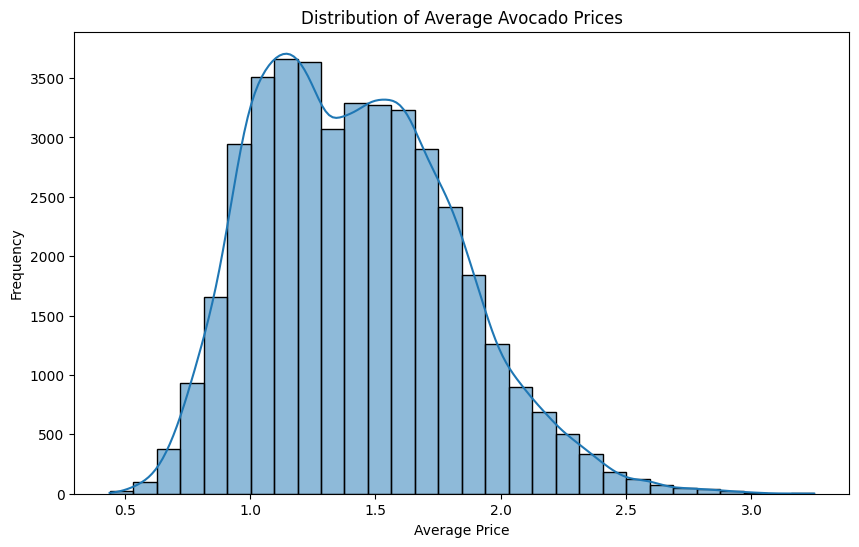

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_avocado_data['AveragePrice'], kde=True, bins=30)
plt.title('Distribution of Average Avocado Prices')
plt.xlabel('Average Price')
plt.ylabel('Frequency')
plt.show()


Results: The histogram shows that the distribution of average avocado prices is right-skewed, with most prices concentrated between 1.0 and 2.0. The peak (mode) occurs around 1.2, while higher prices beyond 2.0 are less frequent, creating a long tail. The distribution suggests that the majority of avocado prices are lower, but there are occasional higher prices, which could impact regression modeling. 

Distribution of Total Avocado Volume Sold

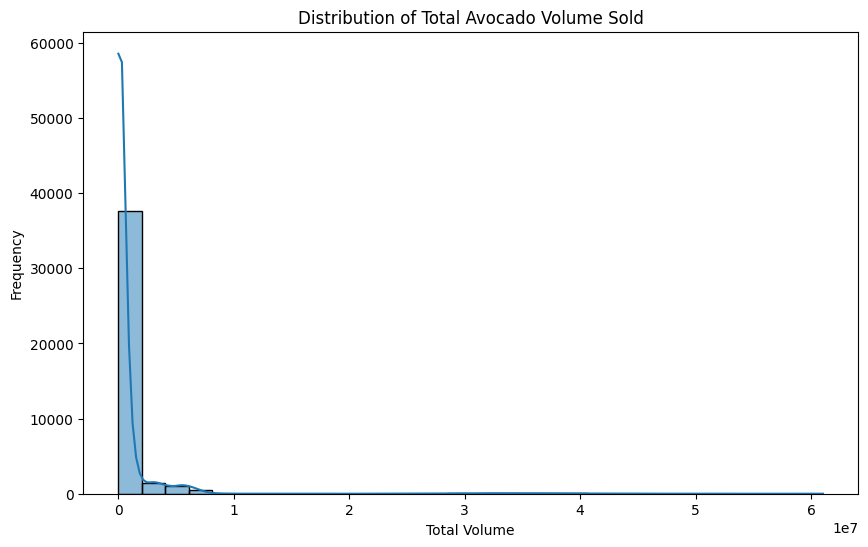

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_avocado_data['TotalVolume'], kde=True, bins=30)
plt.title('Distribution of Total Avocado Volume Sold')
plt.xlabel('Total Volume')
plt.ylabel('Frequency')
plt.show()


Results: The histogram shows the distribution of total avocado volume sold. The data is highly skewed to the right, with most sales volumes concentrated at the lower end. A significant number of data points fall within the lowest volume range, while very few instances exist at higher volume levels. This indicates that smaller volumes are much more common in the dataset.

Distribution of Bag Sizes

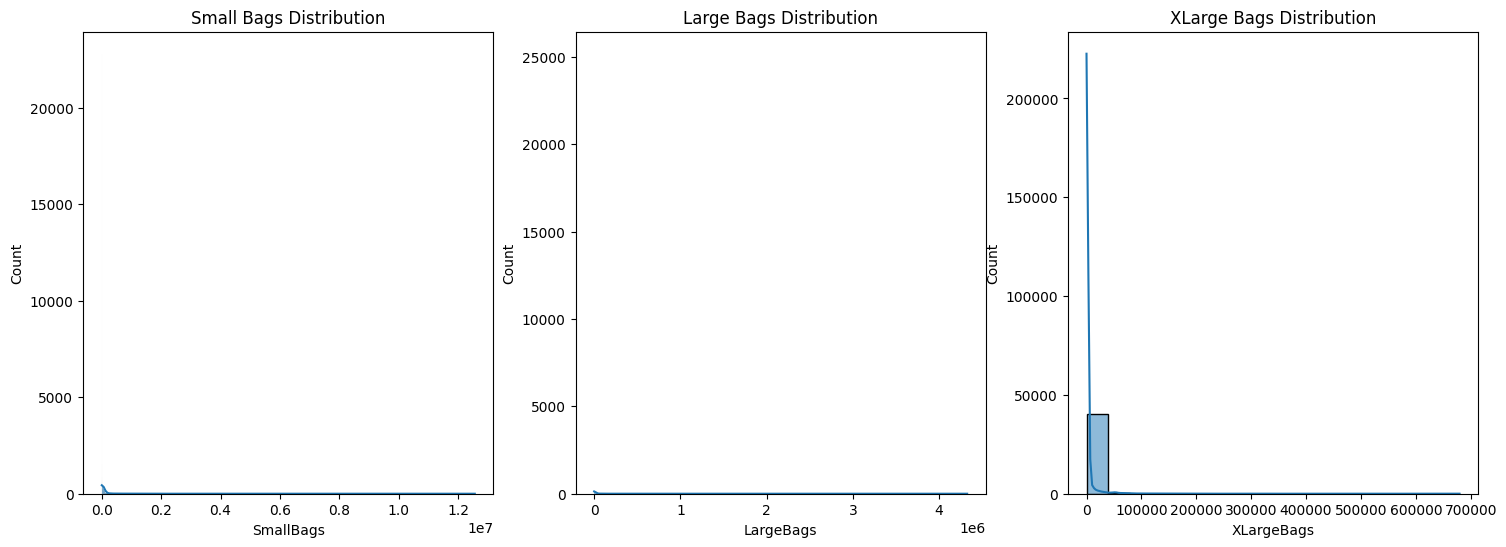

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(cleaned_avocado_data['SmallBags'], kde=True, ax=axs[0])
axs[0].set_title('Small Bags Distribution')

sns.histplot(cleaned_avocado_data['LargeBags'], kde=True, ax=axs[1])
axs[1].set_title('Large Bags Distribution')

sns.histplot(cleaned_avocado_data['XLargeBags'], kde=True, ax=axs[2])
axs[2].set_title('XLarge Bags Distribution')

plt.show()


Results:
The three histograms show the distribution of avocado sales in small, large, and extra-large bags.
Small Bags: The sales are highly concentrated at the lower end, with a sharp decrease as volumes increase. This indicates that small bag sales are mostly low in volume.
Large Bags: Similar to small bags, the sales are predominantly low, showing a steep drop-off as volumes increase, suggesting infrequent high-volume sales.
XLarge Bags: Sales are also concentrated at the lower end, with very few instances of high-volume sales.
Overall, all bag sizes exhibit right-skewed distributions, indicating that most sales occur in lower volumes.

Count of Avocado Types

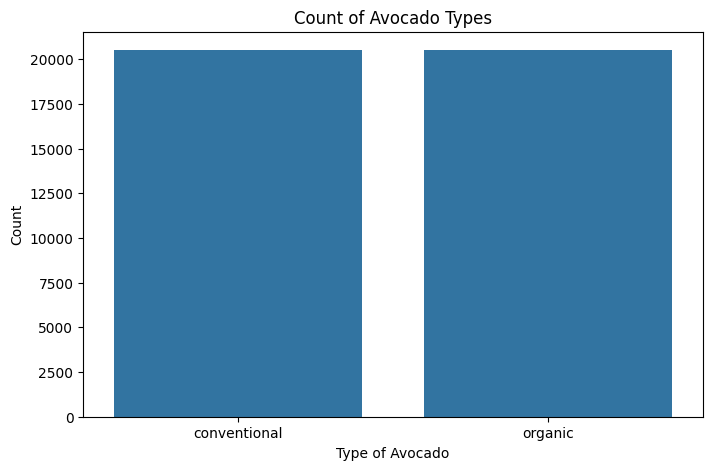

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(data=cleaned_avocado_data, x='type')
plt.title('Count of Avocado Types')
plt.xlabel('Type of Avocado')
plt.ylabel('Count')
plt.show()

Results: The bar chart displays the count of two types of avocados: "conventional" and "organic." The height of both bars is nearly equal, indicating that the dataset contains almost the same number of records for each type of avocado. Each category (conventional and organic) has around 20,000 entries.
This suggests that the dataset is balanced in terms of avocado type, meaning there is no significant disparity between the two categories, making it suitable for comparisons or analysis that involves both types.

Count of Data Points per Region

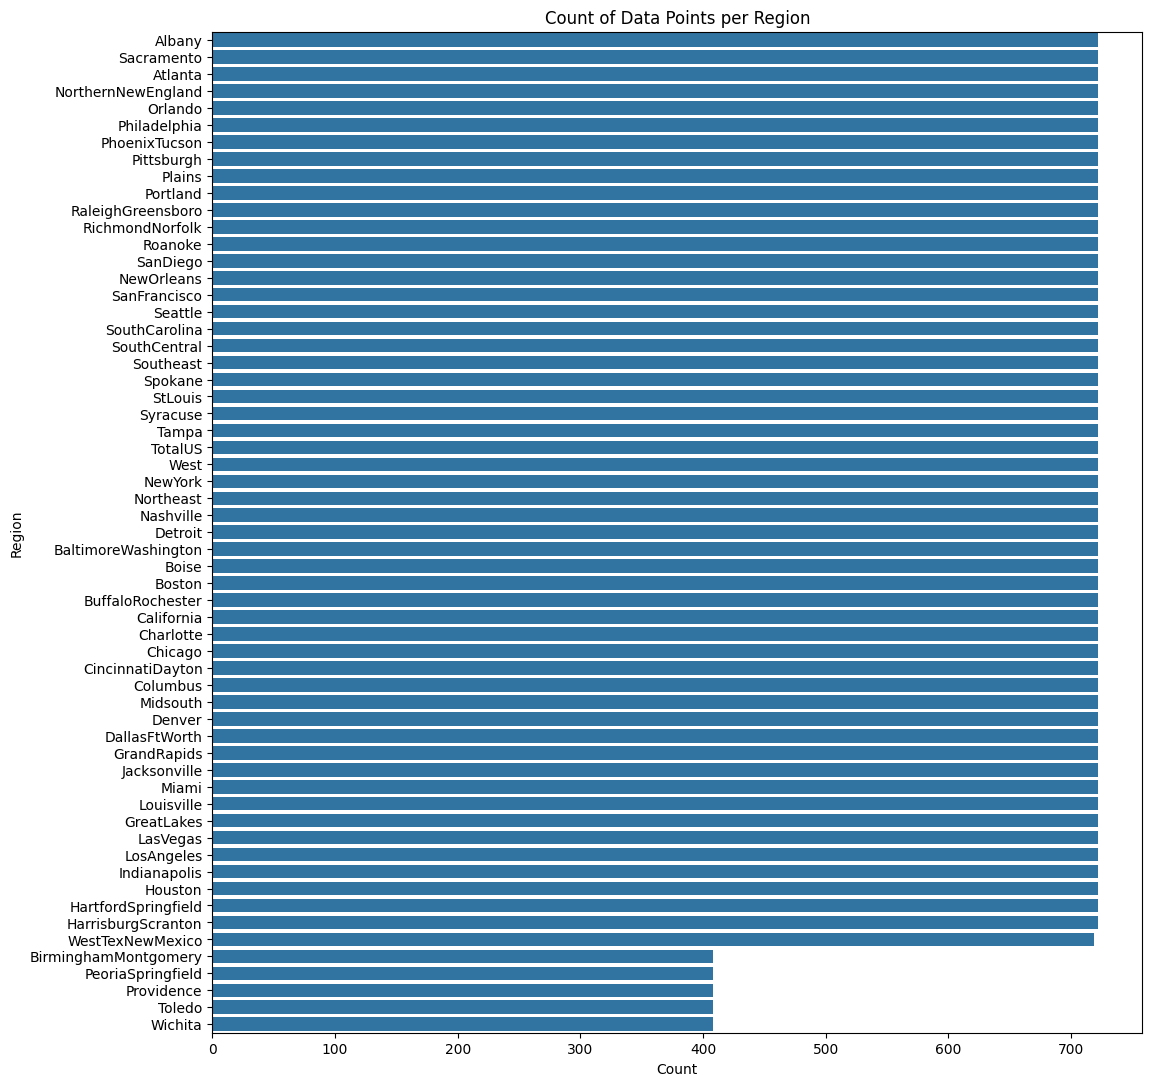

In [11]:
plt.figure(figsize=(12,13))
sns.countplot(y='region', data=cleaned_avocado_data, order=cleaned_avocado_data['region'].value_counts().index)
plt.title('Count of Data Points per Region')
plt.ylabel('Region')
plt.xlabel('Count')
plt.show()


Results: The bar chart illustrates the count of data points per region in the dataset. Most regions have a similar number of data points, around 700, indicating that the dataset is fairly balanced across the regions. However, a few regions, such as PeoriaSpringfield, Providence, Toledo, and Wichita, have noticeably fewer data points, around 400 or less.
This suggests that while the dataset is generally balanced across most regions, there are a handful of regions with fewer data entries, which could impact analyses focused on those areas. For comprehensive results, the imbalance in these few regions should be considered.

Boxplot of Avocado Prices by Type

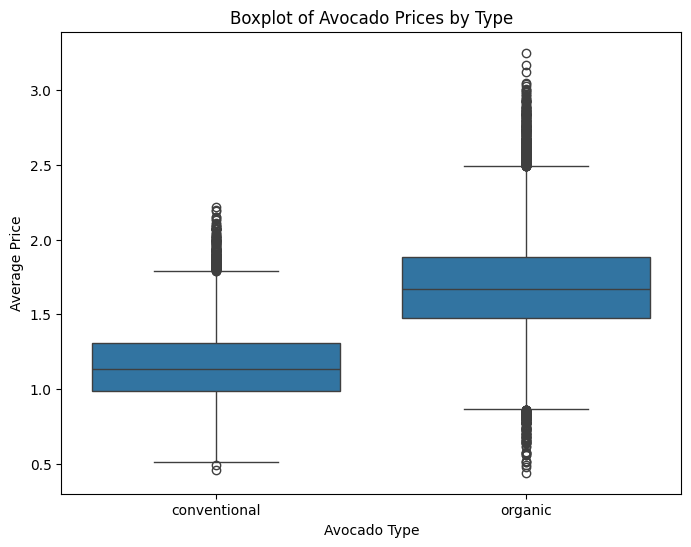

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x='type', y='AveragePrice', data=cleaned_avocado_data)
plt.title('Boxplot of Avocado Prices by Type')
plt.xlabel('Avocado Type')
plt.ylabel('Average Price')
plt.show()


Results: The boxplot compares the average prices of conventional and organic avocados. Organic avocados generally have higher prices, with a median price closer to $1.75, while conventional avocados have a median price of around $1.25. The price distribution for organic avocados shows more variability, with several outliers above $2.50, whereas conventional avocados have fewer outliers, and their prices are more concentrated between $1.00 and $1.50.
This visualization highlights that organic avocados are typically more expensive and exhibit greater price fluctuations compared to conventional avocados.

Total Volume vs Average Price by Type

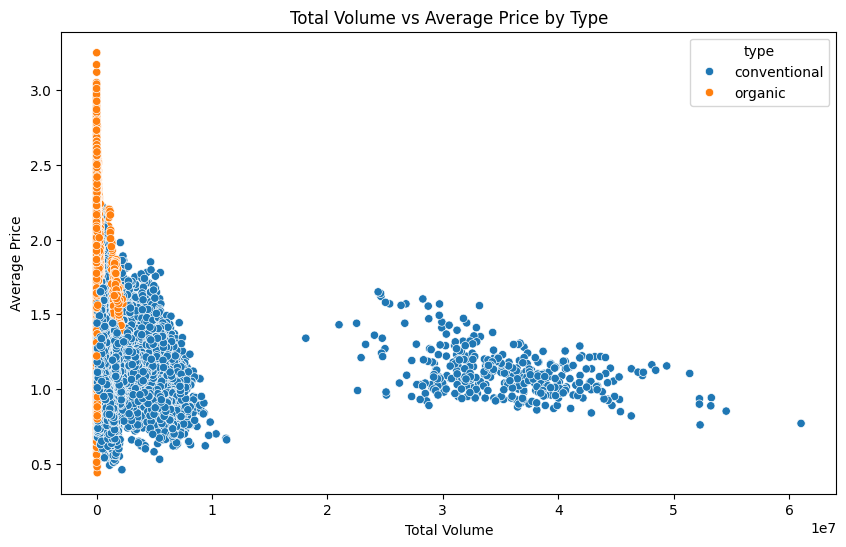

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='TotalVolume', y='AveragePrice', hue='type', data=cleaned_avocado_data)
plt.title('Total Volume vs Average Price by Type')
plt.xlabel('Total Volume')
plt.ylabel('Average Price')
plt.show()


Results: The scatter plot displays the relationship between total volume and average price for two types of products: conventional and organic.
Conventional Products (blue): These have a wide range of total volumes, from low to high, with average prices generally below 1.5. As total volume increases, the average price tends to decrease slightly or remain stable.
Organic Products (orange): These are clustered at lower total volumes with higher average prices, often above 1.5 and up to 3.0.
Overall, conventional products appear to dominate the higher volume range, while organic products tend to be priced higher at lower volumes.

Average Price of Avocados by Region

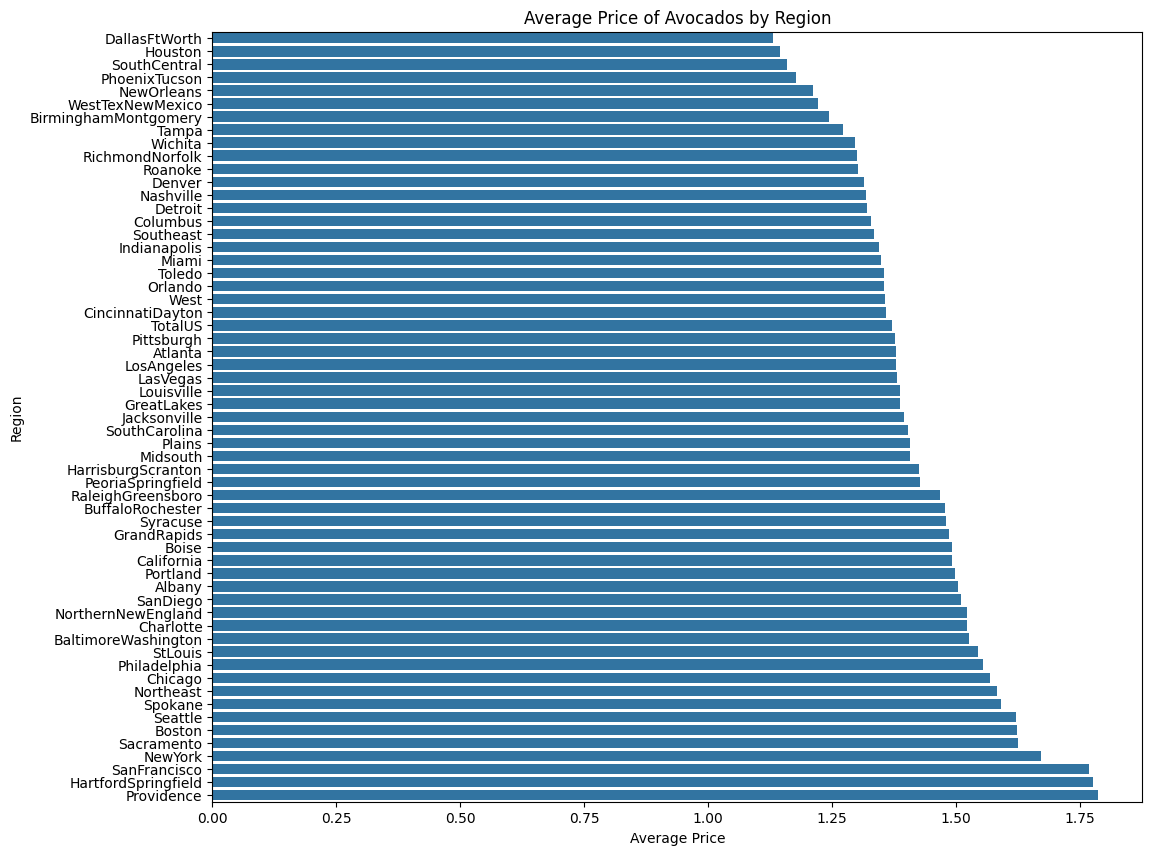

In [14]:
plt.figure(figsize=(12,10))
region_avg_price = cleaned_avocado_data.groupby('region')['AveragePrice'].mean().sort_values()
sns.barplot(x=region_avg_price.values, y=region_avg_price.index)
plt.title('Average Price of Avocados by Region')
plt.xlabel('Average Price')
plt.ylabel('Region')
plt.show()


Results: The bar chart shows the average price of avocados across different regions.
Lowest Prices: Regions like DallasFtWorth, Houston, and SouthCentral have the lowest average prices.
Mid-Range Prices: Many regions, including Southeast, Midwest, and West, fall in the mid-range category.
Highest Prices: Regions such as San Francisco, HartfordSpringfield, and Providence have the highest average prices, approaching or exceeding 1.75.
Overall, there is a noticeable variation in avocado prices across regions, with some areas significantly more expensive than others.

Time-Series Analysis: Avocado Prices Over Time

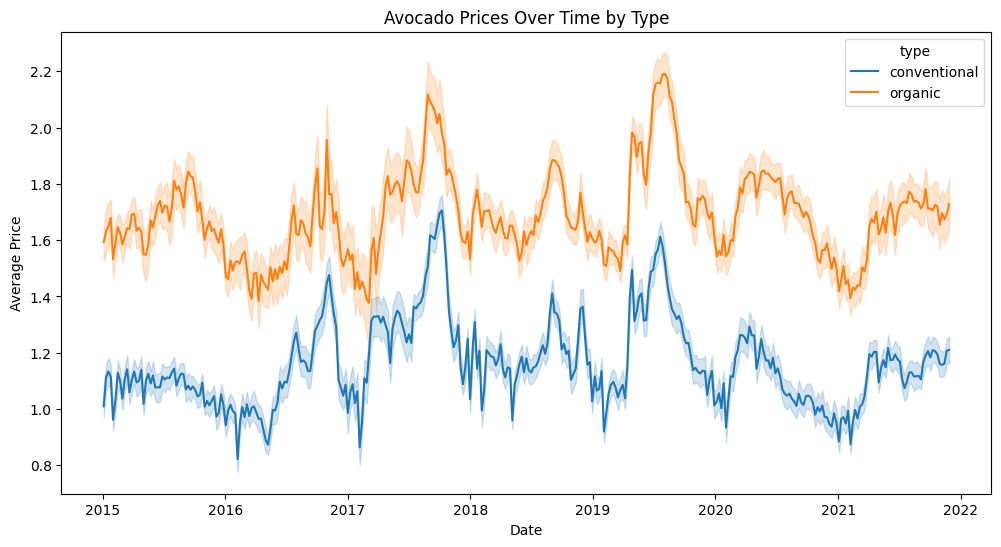

In [15]:
# Convert 'Date' to datetime format if it isn't already
cleaned_avocado_data['Date'] = pd.to_datetime(cleaned_avocado_data['Date'])

plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='AveragePrice', hue='type', data=cleaned_avocado_data)
plt.title('Avocado Prices Over Time by Type')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.show()


Results: This graph shows the trends in avocado prices over time (from 2015 to 2022) for two types of avocados: conventional (in blue) and organic (in orange). Here's a summary of what can be interpreted:
Organic avocados are consistently priced higher than conventional ones.
Both types experience seasonal fluctuations, with notable price peaks in 2017 and 2019.
Prices have shown a slight downward trend by the end of the graph, but organic avocados remain pricier.

Total Volume vs Total Bags by Type

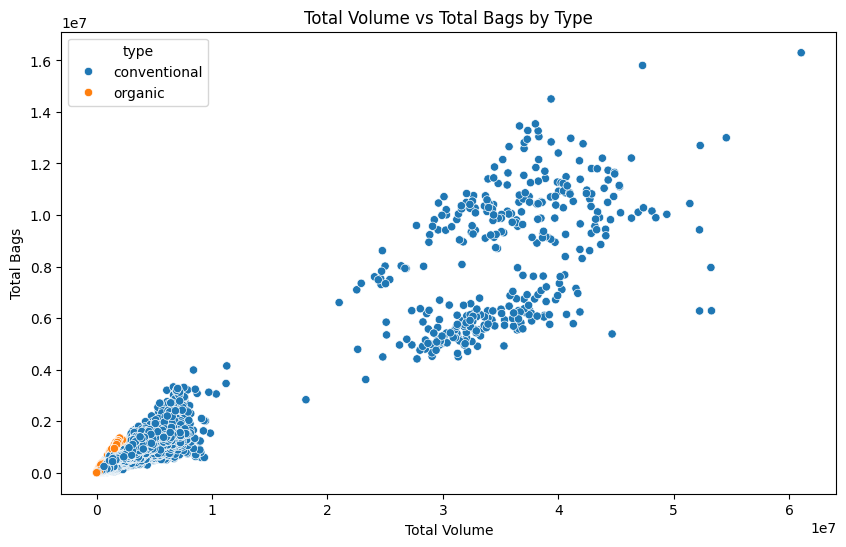

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='TotalVolume', y='TotalBags', hue='type', data=cleaned_avocado_data)
plt.title('Total Volume vs Total Bags by Type')
plt.xlabel('Total Volume')
plt.ylabel('Total Bags')
plt.show()


Results: This scatter plot shows the relationship between Total Volume of avocados sold and the Total Bags used, broken down by type (conventional and organic). Here's an interpretation of the graph:
Conventional avocados dominate the market, with significantly higher total volumes and bag usage compared to organic avocados.
The correlation between total volume and total bags is stronger and more varied for conventional avocados, which operate on a larger scale.
Organic avocados have a more limited volume and bag usage, as shown by their clustering in the lower range of the graph.
The relationship for both types is positive, but organic avocados occupy a much smaller range in terms of sales and packaging volume.

<a href="#six"></a>
## **Data Preprocessing**
<a href="#cont">Back to Table of Contents</a>

* **Purpose:**
  Data preprocessing is essential to prepare raw data for analysis by cleaning, transforming, and organizing it. This step ensures that the data is accurate, complete, and in a format suitable for modeling and analysis.

* **Details:**
  1. **Cleaning:** Remove or correct any inaccuracies, inconsistencies, or missing values in the dataset. This may involve handling outliers, filling in missing values, or removing duplicate entries.
  2. **Transformation:** Convert data into the appropriate format or structure needed for analysis. This can include normalization, encoding categorical variables, and feature scaling to ensure that the data meets the requirements of analytical methods or algorithms.



Checking and handling missing values

In [9]:
df = cleaned_avocado_data.copy()

# Checking for missing values
print(df.isnull().sum())

# For numerical columns with missing values, fill with the mean
from sklearn.impute import SimpleImputer

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# For categorical columns, fill missing with the most frequent value
categorical_cols = df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

Date            0
AveragePrice    0
TotalVolume     0
plu4046         0
plu4225         0
plu4770         0
TotalBags       0
SmallBags       0
LargeBags       0
XLargeBags      0
type            0
region          0
dtype: int64


Handling Outliers

In [10]:
from scipy import stats
import numpy as np

# Z-score to identify outliers for each numerical column
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    # Keeping rows where z-score is less than 3 (removes extreme outliers)
    df = df[z_scores < 3]

# Check the dataset after removing outliers
print(df.shape)


(34649, 12)


Encoding categorical columns

In [11]:
# One-hot encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check the new shape after encoding
print(df_encoded.head())


   AveragePrice  TotalVolume    plu4046    plu4225   plu4770  TotalBags  \
0          1.22     40873.28    2819.50   28287.42     49.90    9716.46   
1          1.79      1373.95      57.42     153.88      0.00    1162.65   
2          1.00    435021.49  364302.39   23821.16     82.15   46815.79   
3          1.76      3846.69    1500.15     938.35      0.00    1408.19   
4          1.08    788025.06   53987.31  552906.04  39995.03  141136.68   

   SmallBags  LargeBags  XLargeBags  Date_2015-01-11  ...  region_Southeast  \
0    9186.93     529.53         0.0            False  ...             False   
1    1162.65       0.00         0.0            False  ...             False   
2   16707.15   30108.64         0.0            False  ...             False   
3    1071.35     336.84         0.0            False  ...             False   
4  137146.07    3990.61         0.0            False  ...             False   

   region_Spokane  region_StLouis  region_Syracuse  region_Tampa  \
0     

In [21]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical features
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Inspect the scaled data
print(df_encoded.head())


        Date  AveragePrice  TotalVolume   plu4046   plu4225   plu4770  \
0 2015-01-04     -0.650040    -0.504551 -0.427111 -0.231313 -0.335171   
1 2015-01-04      0.844509    -0.634347 -0.448920 -0.491011 -0.340717   
2 2015-01-04     -1.226884     0.790633  2.427111 -0.272541 -0.331587   
3 2015-01-04      0.765849    -0.626222 -0.437528 -0.483769 -0.340717   
4 2015-01-04     -1.017123     1.950615 -0.023096  4.611377  4.104144   

   TotalBags  SmallBags  LargeBags  XLargeBags  ...  region_Southeast  \
0  -0.593795  -0.239633  -0.288061   -0.235717  ...             False   
1  -0.729326  -0.474202  -0.342413   -0.235717  ...             False   
2  -0.005975  -0.019799   2.747997   -0.235717  ...             False   
3  -0.725436  -0.476871  -0.307839   -0.235717  ...             False   
4   1.488493   3.500912   0.067191   -0.235717  ...             False   

   region_Spokane  region_StLouis  region_Syracuse  region_Tampa  \
0           False           False            False    

Spliting the dataset into training and testing sets.

In [12]:
from sklearn.model_selection import train_test_split

# Assuming 'AveragePrice' is the target variable (regression problem)
X = df_encoded.drop('AveragePrice', axis=1)  # Drop target
y = df_encoded['AveragePrice']  # Target

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the train and test sets
print(X_train.shape, X_test.shape)


(27719, 427) (6930, 427)


---
<a href=#six></a>
## **Modeling**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Develop and train predictive or statistical models.
* **Details:** Describe the choice of models, feature selection and engineering processes, and show how the models are trained. Include code for setting up the models and explanations of the model parameters.
---


In [13]:
# Import models and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor(random_state=42)
gradient_boost_model = GradientBoostingRegressor(random_state=42)

### Model Training

### Prediction

---
<a href=#seven></a>
## **Evaluation and Validation**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Evaluate and validate the effectiveness and accuracy of the models.
* **Details:** Present metrics used to evaluate the models, such as accuracy, precision, recall, F1-score, etc. Discuss validation techniques employed, such as cross-validation or train/test split.
---

In [ ]:
# Evaluate Linear Regression
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Evaluate Random Forest Regressor
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Evaluate Gradient Boosting Regressor
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print evaluation results
print("Linear Regression: MSE =", mse_linear, ", R2 Score =", r2_linear)
print("Random Forest Regressor: MSE =", mse_rf, ", R2 Score =", r2_rf)
print("Gradient Boosting Regressor: MSE =", mse_gb, ", R2 Score =", r2_gb)

---
<a href=#eight></a>
## **Final Model**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Present the final model and its performance.
* **Details:** Highlight the best-performing model and discuss its configuration, performance, and why it was chosen over others.
---


In [ ]:
#Please use code cells to code in and do not forget to comment your code.

---
<a href=#nine></a>
## **Conclusion and Future Work**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Summarize the findings and discuss future directions.
* **Details:** Conclude with a summary of the results, insights gained, limitations of the study, and suggestions for future projects or improvements in methodology or data collection.
---


In [ ]:
#Please use code cells to code in and do not forget to comment your code.

---
<a href=#ten></a>
## **References**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Provide citations and sources of external content.
* **Details:** List all the references and sources consulted during the project, including data sources, research papers, and documentation for tools and libraries used.
---

In [ ]:
#Please use code cells to code in and do not forget to comment your code.

## Additional Sections to Consider

* ### Appendix: 
For any additional code, detailed tables, or extended data visualizations that are supplementary to the main content.

* ### Contributors: 
If this is a group project, list the contributors and their roles or contributions to the project.
